In [1]:
import torch
from torch import nn
import torch.optim as optim
import torch.nn.functional as F
from utils.callbacks import ModelCheckpoint
from utils.dataset import DatasetBuilder as db
from utils.trainer import fit, evaluate_regression
from utils.visualizer import plot_training_curves
from utils.logger import save_run


In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if device.type == 'cuda':
    torch.backends.cudnn.benchmark = True
print(f'Using device: {device}')

Using device: cuda


In [3]:
images_data, lables_data = db.load_bbox_dataset(
    './Images/',
    './label',
    normalize_bbox=True,
)

In [4]:
train_loader, val_loader, test_loader = db.create_dataloaders(
    images_data,
    lables_data,
    batch_size=128,
)

In [5]:
class ObjectDetector(nn.Module):
    def __init__(self):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.block4 = nn.Sequential(
            nn.Conv2d(128, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.bottleneck = nn.Sequential(
            nn.Conv2d(64, 32, 1), nn.ReLU()
        )
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 4)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.bottleneck(x)
        return self.head(x)


In [7]:
model = ObjectDetector().to(device)
print(model)
print(f'\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}')

ObjectDetector(
  (block1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block4): Sequential(
    (0): Conv2d(128, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1)

In [8]:

epochs = 50
criterion = nn.HuberLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)

scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=0.1,
    steps_per_epoch=len(train_loader),
    epochs=epochs,
    pct_start=0.3,
    anneal_strategy='cos',
    div_factor=25,
    final_div_factor=1e4,
)

scaler = torch.amp.GradScaler('cuda')

checkpoint = ModelCheckpoint(
    model=model,
    checkpoint_path='checkpoint/od_checkpoint_light.pth',
    best_model_path='checkpoint/best_od_checkpoint_light.pth',
    mode='max',
    verbose=True,
)

In [9]:
history = fit(
    model=model, task_type='regression',
    trainloader=train_loader, valloader=val_loader,
    criterion=criterion, optimizer=optimizer, scheduler=scheduler,
    device=device, epochs=epochs, scaler=scaler, checkpoint=checkpoint,
)

[ModelCheckpoint] New best (max): 0.6389 — saved to checkpoint\best_od_checkpoint_.pth
Epoch [ 1/50] | Train Loss: 0.0148 | Val Loss: 0.0008 | Val MAE: 0.0279 | Val IoU: 0.6389 | Time: 10.06s
[ModelCheckpoint] New best (max): 0.7057 — saved to checkpoint\best_od_checkpoint_.pth
Epoch [ 2/50] | Train Loss: 0.0020 | Val Loss: 0.0004 | Val MAE: 0.0211 | Val IoU: 0.7057 | Time: 4.84s
[ModelCheckpoint] New best (max): 0.7532 — saved to checkpoint\best_od_checkpoint_.pth
Epoch [ 3/50] | Train Loss: 0.0015 | Val Loss: 0.0003 | Val MAE: 0.0170 | Val IoU: 0.7532 | Time: 4.64s
[ModelCheckpoint] New best (max): 0.7730 — saved to checkpoint\best_od_checkpoint_.pth
Epoch [ 4/50] | Train Loss: 0.0011 | Val Loss: 0.0002 | Val MAE: 0.0153 | Val IoU: 0.7730 | Time: 4.62s
[ModelCheckpoint] New best (max): 0.7874 — saved to checkpoint\best_od_checkpoint_.pth
Epoch [ 5/50] | Train Loss: 0.0009 | Val Loss: 0.0002 | Val MAE: 0.0141 | Val IoU: 0.7874 | Time: 4.59s
[ModelCheckpoint] New best (max): 0.8134 — s

[ModelCheckpoint] Restored best weights from checkpoint\best_od_checkpoint_.pth (score=0.8982)


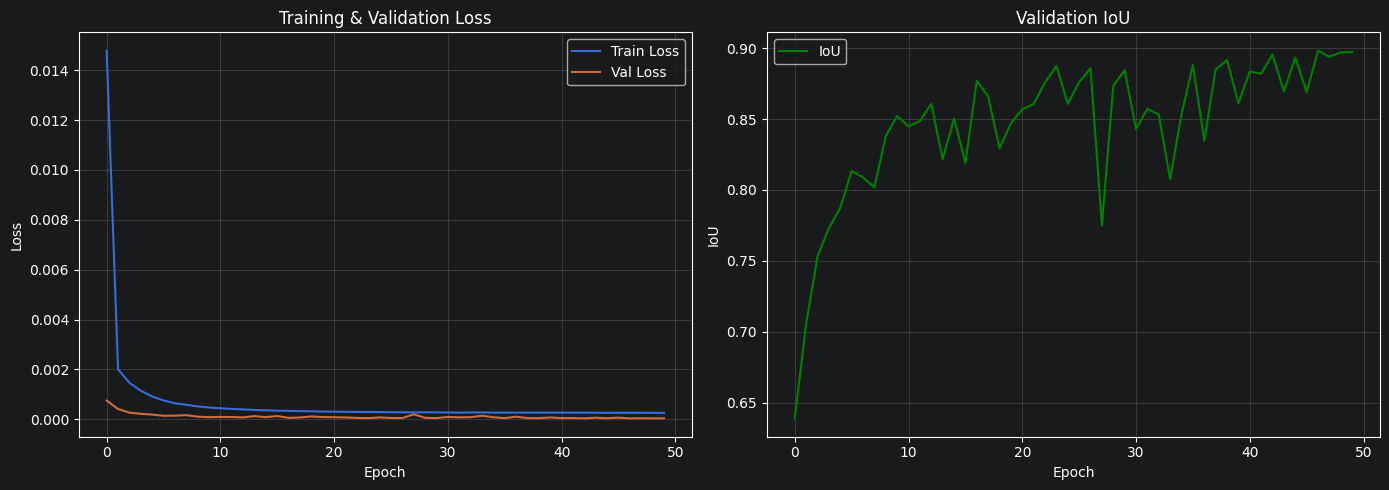

In [10]:
checkpoint.restore_best_weights()

plot_training_curves(
    history["train_loss"],
    history["val_loss"],
    history["val_iou"],
    metric_label="IoU"
)

## Test Set Evaluation

In [11]:
from utils.trainer import evaluate_regression

test_loss, test_mae, test_iou = evaluate_regression(model, test_loader, criterion, device)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test MAE:  {test_mae:.4f}")
print(f"Test IoU:  {test_iou:.4f}")

Test Loss: 0.0000
Test MAE:  0.0062
Test IoU:  0.8968


## Visual Detections on Test Samples

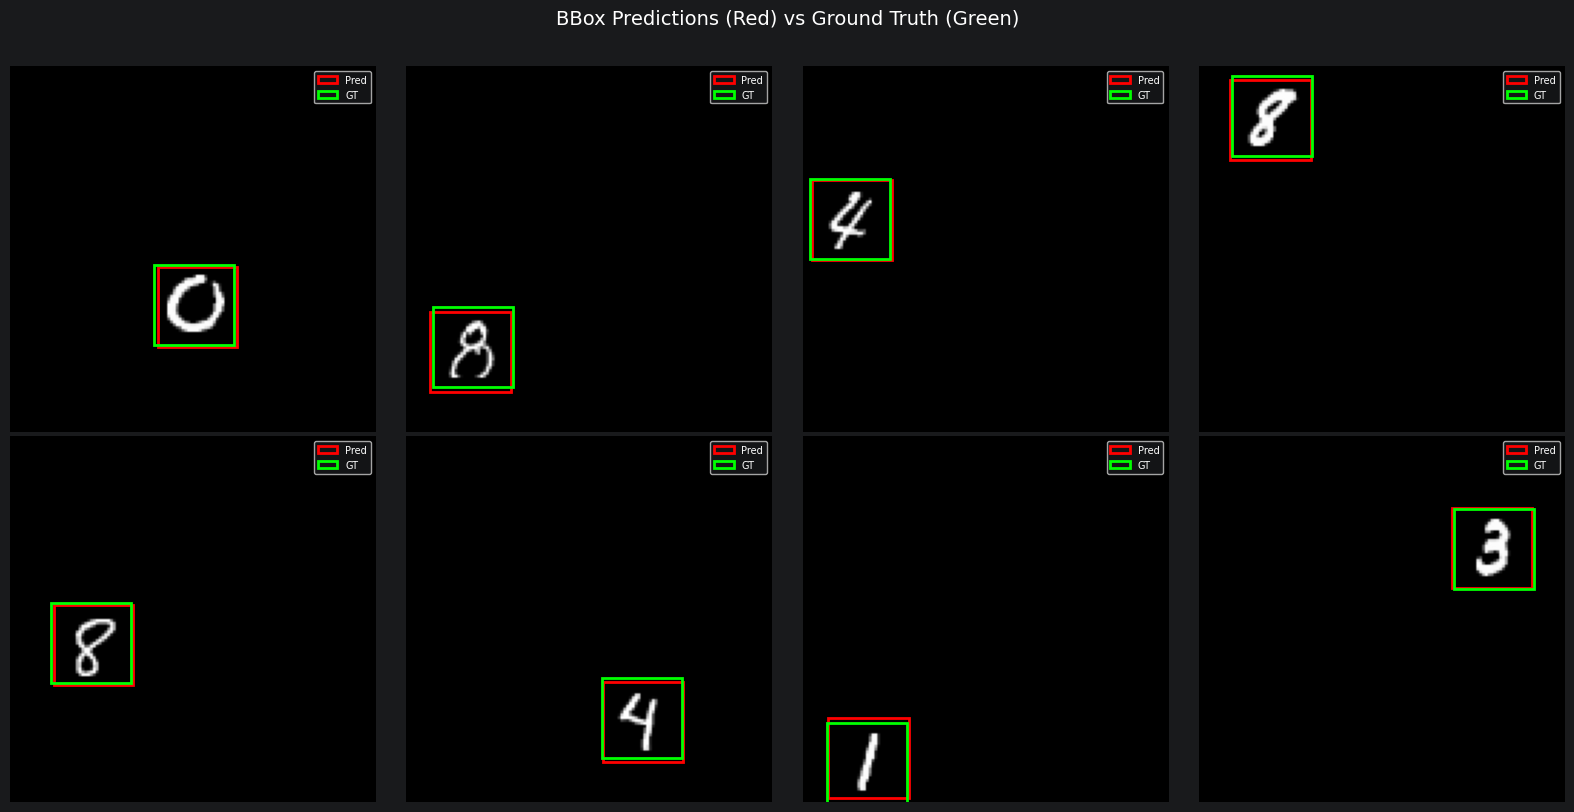

In [12]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

model.eval()
n_samples = 8
cols = 4
rows = n_samples // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
axes = axes.flatten()

sample_count = 0
with torch.no_grad():
    for images, bboxes in test_loader:
        images, bboxes = images.to(device), bboxes.to(device)
        preds = model(images)

        for i in range(len(images)):
            if sample_count >= n_samples:
                break

            img_np = images[i].cpu().squeeze().numpy()
            pred = preds[i].cpu().numpy()
            actual = bboxes[i].cpu().numpy()
            H, W = 128, 128

            ax = axes[sample_count]
            ax.imshow(img_np, cmap="gray")

            # Predicted box (red)
            ax.add_patch(patches.Rectangle(
                (pred[0]*W, pred[1]*H),
                (pred[2]-pred[0])*W, (pred[3]-pred[1])*H,
                linewidth=2, edgecolor="red", facecolor="none", label="Pred"
            ))
            # Ground truth box (green)
            ax.add_patch(patches.Rectangle(
                (actual[0]*W, actual[1]*H),
                (actual[2]-actual[0])*W, (actual[3]-actual[1])*H,
                linewidth=2, edgecolor="lime", facecolor="none", label="GT"
            ))

            ax.legend(loc="upper right", fontsize=7)
            ax.axis("off")
            sample_count += 1

        if sample_count >= n_samples:
            break

plt.suptitle("BBox Predictions (Red) vs Ground Truth (Green)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Save Final Model

In [13]:
# Save model weights
torch.save(model.state_dict(), "./Models/bbox_model_torch.pth")
print("Model saved to ./Models/bbox_model_torch.pth")

# Save training run history + model info
save_run(
    "logs/bbox_run_stratA.json",
    model,
    history,
    epochs=epochs,
    batch_size=128,
    optimizer="SGD",
    loss="HuberLoss",
    scheduler="OneCycleLR",
)


Model saved to ./Models/bbox_model_torch.pth
Run saved → logs/bbox_run_stratA.json


In [14]:
import pandas as pd
df = pd.DataFrame(history)
import time
df.to_csv(f'log/run_{time.strftime("%Y%m%d-%H%M%S")}.csv', index=False)

NameError: name 'pd' is not defined